z=0.51 train: excluding 103/50000
z=0.51 val: excluding 13/5000
z=0.51 test: excluding 15/5000
z=0.706 train: excluding 88/50000
z=0.706 val: excluding 13/5000
z=0.706 test: excluding 5/5000
z=0.919 train: excluding 85/50000
z=0.919 val: excluding 8/5000
z=0.919 test: excluding 9/5000
z=1.317 train: excluding 81/50000
z=1.317 val: excluding 6/5000
z=1.317 test: excluding 10/5000
z=1.491 train: excluding 99/50000
z=1.491 val: excluding 18/5000
z=1.491 test: excluding 9/5000


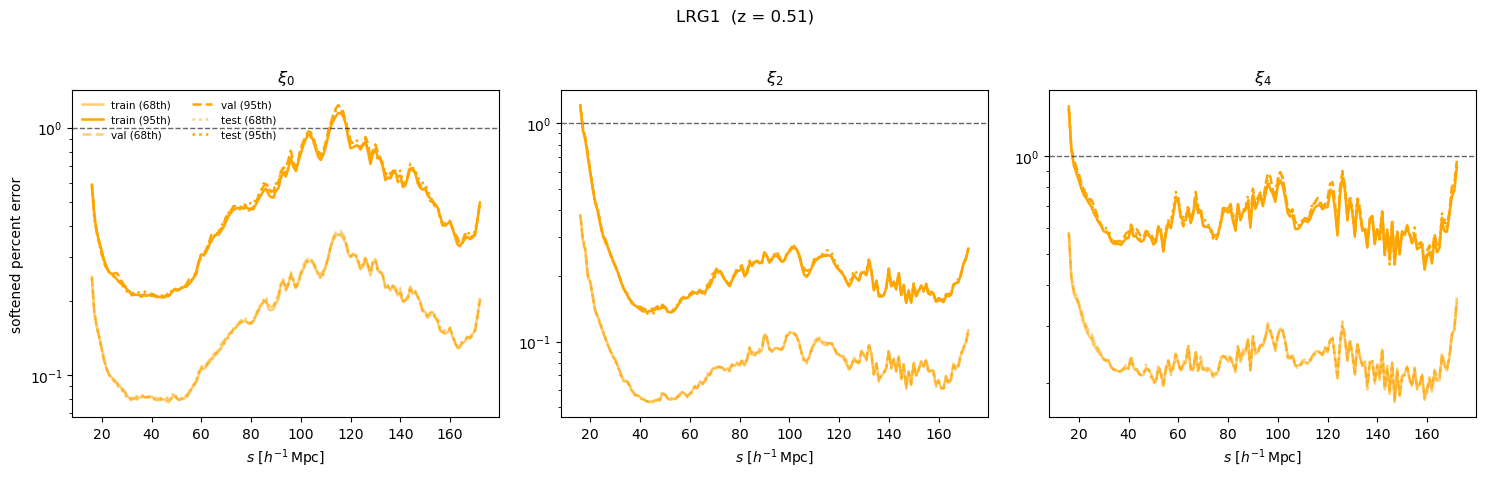

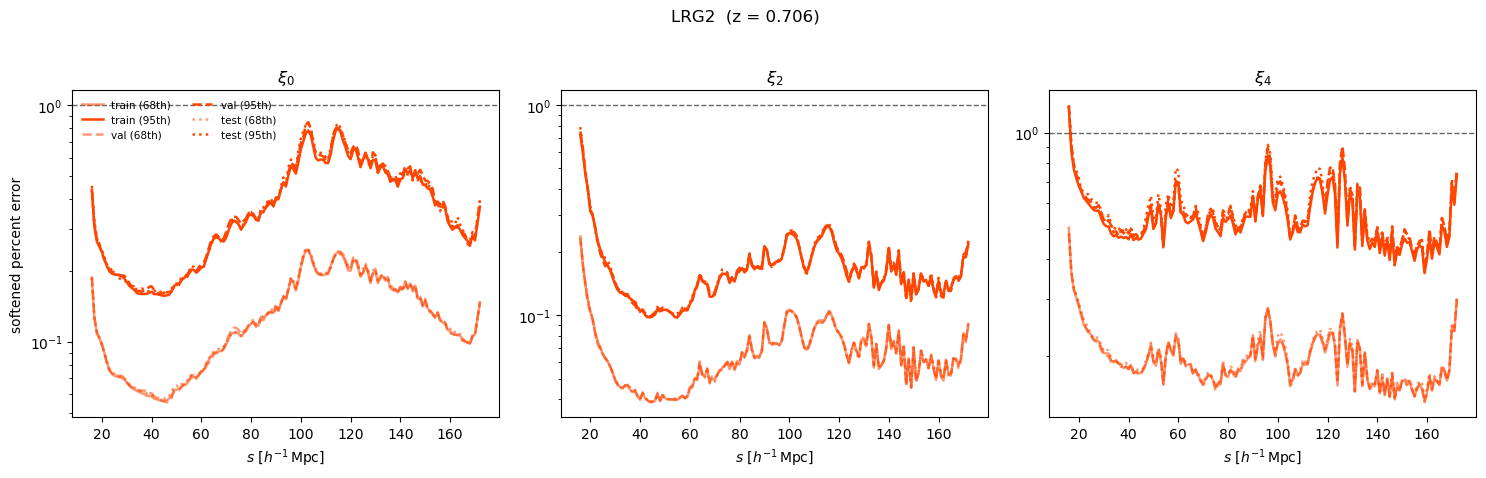

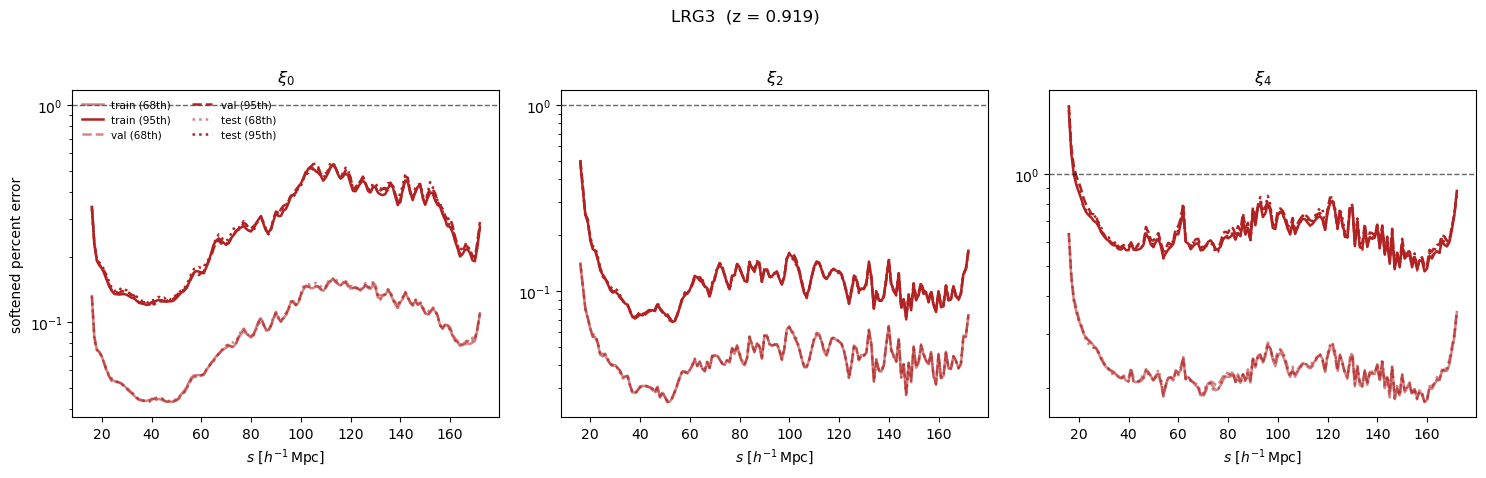

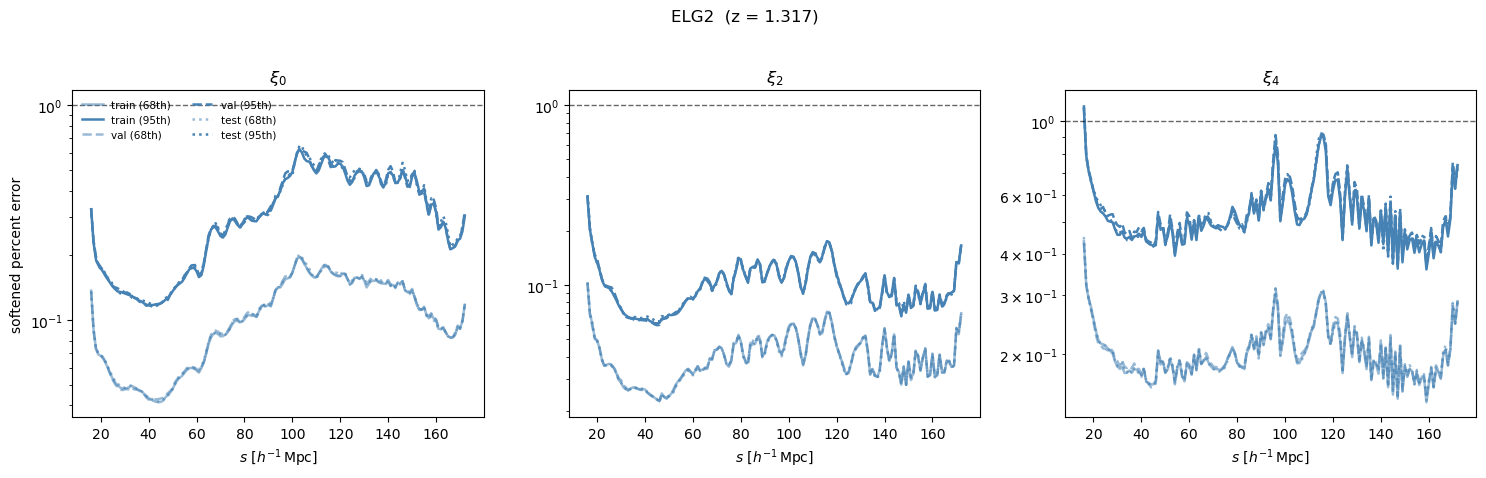

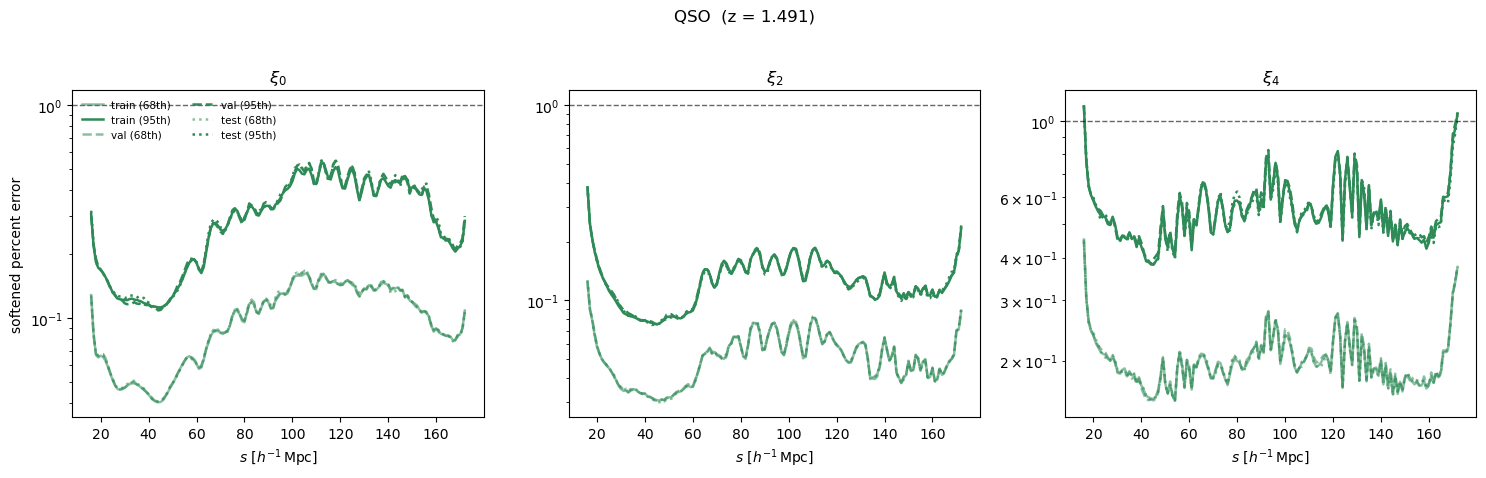

In [ ]:
"""
Percentile-error plots for xi_0, xi_2, xi_4, at each trained redshift --
train/val/test overlaid on the same axes (so overfitting is visible directly),
using a softened percent-error metric that floors out near truth's zero
crossings instead of diverging, and DESI's own per-tracer color scheme
(DESI 2024 II, Appendix D) since these redshifts are exactly the DESI DR1
tracer effective redshifts.
"""

import os
import sys
sys.path.insert(0, '/home/cosweeney/code/EmulateLSS')
from emulator import Emulator as NPEmulator   # numpy inference class -- applies sinh()/mean/sigmas internally

import numpy as np
import matplotlib.pyplot as plt



REDSHIFTS = [0.510, 0.706, 0.919, 1.317, 1.491]
ELLS = (0, 2, 4)
BASE_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set_free_ns/'
MODEL_DIR = '/spiffball/cosweeney/data/models_free_ns/'
OUT_DIR = '/spiffball/cosweeney/data/plots_free_ns/'
os.makedirs(OUT_DIR, exist_ok=True)

# DESI 2024 II (arXiv:2411.12020), Appendix D -- official per-tracer colors.
# z=0.919 here stands in for DESI's z_eff=0.920 LRG3 bin.
TRACER_COLOR = {
    0.510: ('LRG1', 'orange'),
    0.706: ('LRG2', 'orangered'),
    0.919: ('LRG3', 'firebrick'),
    1.317: ('ELG2', 'steelblue'),
    1.491: ('QSO',  'seagreen'),
}

SPLITS = {'train': '-', 'val': '--', 'test': ':'}
PCTS = [68, 95]                       # trimmed from 4 -> 2 given 3 splits are now overlaid
SHADE = {68: 0.55, 95: 1.0}           # lighter = lower percentile, within one tracer color


def zdir(z):
    return f"z{str(z).replace('.', 'p')}"


def to_params(thetas):
    p = thetas.copy()
    p[:, 5] = np.log(1e10 * thetas[:, 5])
    return p


def flag(xi, rough_ref=None):
    xi0 = xi[:, 0]
    finite = np.isfinite(xi).all(axis=(1, 2))
    collapsed = (np.median(xi0, axis=1) < -0.5) | (np.abs(xi[:, 1]).max(axis=1) < 1e-8)
    rough = np.abs(np.diff(xi0, n=2, axis=1)).mean(axis=1) / np.abs(xi0).mean(axis=1)
    if rough_ref is None:
        rough_ref = np.median(rough[finite & ~collapsed])
    noisy = rough > 5 * rough_ref
    amp = np.abs(xi).max(axis=(1, 2))
    bad = ~finite | (amp > 10) | collapsed | noisy
    return bad, rough_ref


def soft_frac_pct(pred, truth, sigma_s, floor=0.3):
    """Percent-like error that floors out near truth's zero crossings instead
    of diverging: denom -> floor*sigma_s (a fixed, non-vanishing number) as
    truth -> 0, and denom -> |truth| (the ordinary fractional metric) away
    from a crossing."""
    denom = np.sqrt(truth**2 + (floor * sigma_s)**2)
    return 100 * np.abs(pred - truth) / denom


for z in REDSHIFTS:
    tracer_name, base_color = TRACER_COLOR[z]
    z_dir = os.path.join(BASE_DIR, zdir(z))
    s = np.load(os.path.join(z_dir, 's.npy'))

    data = {}
    for split in SPLITS:
        thetas = np.load(os.path.join(z_dir, f'thetas_{split}.npy'))
        xi = np.load(os.path.join(z_dir, f'xi_{split}.npy'))
        data[split] = dict(thetas=thetas, xi=xi)

    _, rough_ref = flag(data['train']['xi'])
    for split in SPLITS:
        bad, _ = flag(data[split]['xi'], rough_ref=rough_ref)
        data[split]['keep'] = ~bad
        print(f"z={z} {split}: excluding {bad.sum()}/{len(bad)}")

    preds = {split: {} for split in SPLITS}
    truths = {split: {} for split in SPLITS}
    sigma_s_train = {}   # softening floor always uses TRAIN's own scatter,
                         # so the metric's denominator means the same thing
                         # across splits rather than each split softening
                         # against its own (differently-sized) sample

    for i, ell in enumerate(ELLS):
        model_path = os.path.join(MODEL_DIR, f'compact_xi{ell}_{zdir(z)}_free_ns')
        emu = NPEmulator(model_path)
        sigma_s_train[ell] = np.std(data['train']['xi'][data['train']['keep']][:, i], axis=0)

        for split in SPLITS:
            th = data[split]['thetas'][data[split]['keep']]
            xi = data[split]['xi'][data[split]['keep']][:, i]
            params = to_params(th)
            _, pred = emu(params)
            preds[split][ell] = pred
            truths[split][ell] = xi

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True)
    for ax, ell in zip(axes, ELLS):
        for split, ls in SPLITS.items():
            frac = soft_frac_pct(preds[split][ell], truths[split][ell], sigma_s_train[ell])
            for p in PCTS:
                c = np.percentile(frac, p, axis=0)
                ax.plot(s, c, color=base_color, ls=ls, alpha=SHADE[p], lw=1.8)
        ax.axhline(1.0, color='k', ls='--', lw=1.0, alpha=0.6)
        ax.set_yscale('log')
        ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
        ax.set_title(rf'$\xi_{ell}$', fontsize=12)

    # build a compact legend by hand -- (split x percentile) combos, not
    # (split x ell) or anything that would duplicate across subplots
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=base_color, ls=ls, alpha=SHADE[p], lw=1.8,
                      label=f'{split} ({p}th)')
              for split, ls in SPLITS.items() for p in PCTS]
    axes[0].set_ylabel('softened percent error')
    axes[0].legend(handles=handles, frameon=False, fontsize=7.5, ncol=2, loc='upper left')
    fig.suptitle(f'{tracer_name}  (z = {z})', y=1.03)
    fig.tight_layout()
#     fig.savefig(os.path.join(OUT_DIR, f'percentile_soft_{zdir(z)}.png'), dpi=130, bbox_inches='tight')
#     plt.close(fig)
#     print(f"z={z} ({tracer_name}): saved percentile_soft_{zdir(z)}.png")

# print(f"\nAll figures written to {OUT_DIR}")

In [5]:
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

In [6]:

def soft_frac_pct(pred, truth, sigma_s, floor=0.3):
    """Percent-like error that floors out near truth's zero crossings instead
    of diverging: denom -> floor*sigma_s (a fixed, non-vanishing number) as
    truth -> 0, and denom -> |truth| (the ordinary fractional metric) away
    from a crossing."""
    denom = np.sqrt(truth**2 + (floor * sigma_s)**2)
    return np.abs(pred - truth) / denom

z=0.51 train: excluding 103/50000
z=0.51 val: excluding 13/5000
z=0.51 test: excluding 15/5000
z=0.706 train: excluding 88/50000
z=0.706 val: excluding 13/5000
z=0.706 test: excluding 5/5000
z=0.919 train: excluding 85/50000
z=0.919 val: excluding 8/5000
z=0.919 test: excluding 9/5000
z=1.317 train: excluding 81/50000
z=1.317 val: excluding 6/5000
z=1.317 test: excluding 10/5000
z=1.491 train: excluding 99/50000
z=1.491 val: excluding 18/5000
z=1.491 test: excluding 9/5000


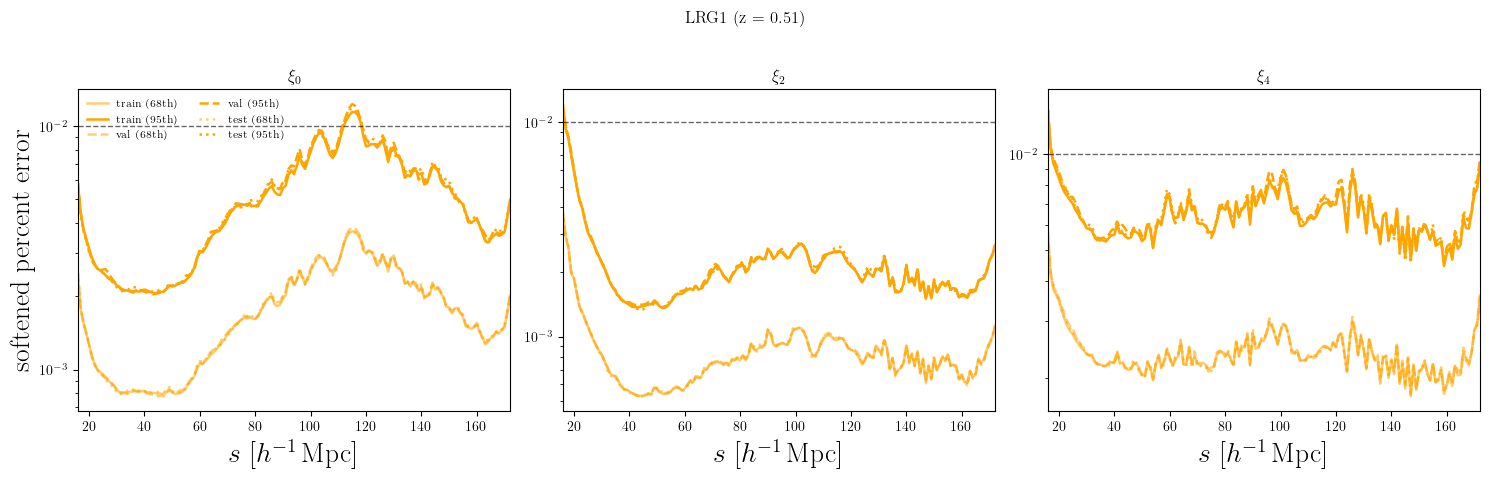

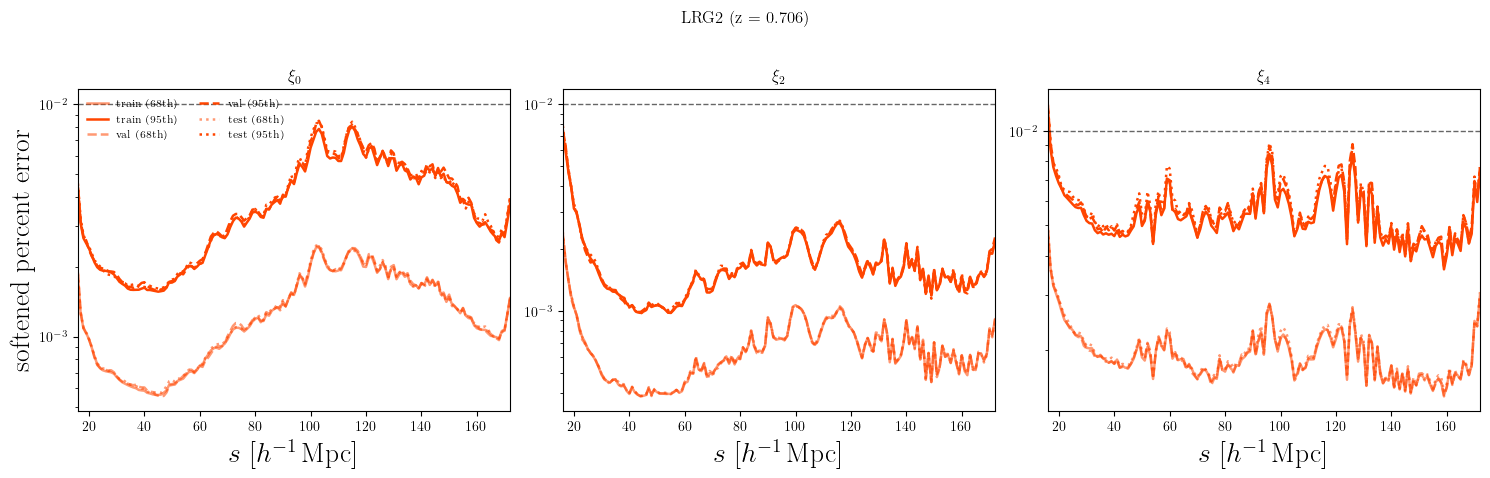

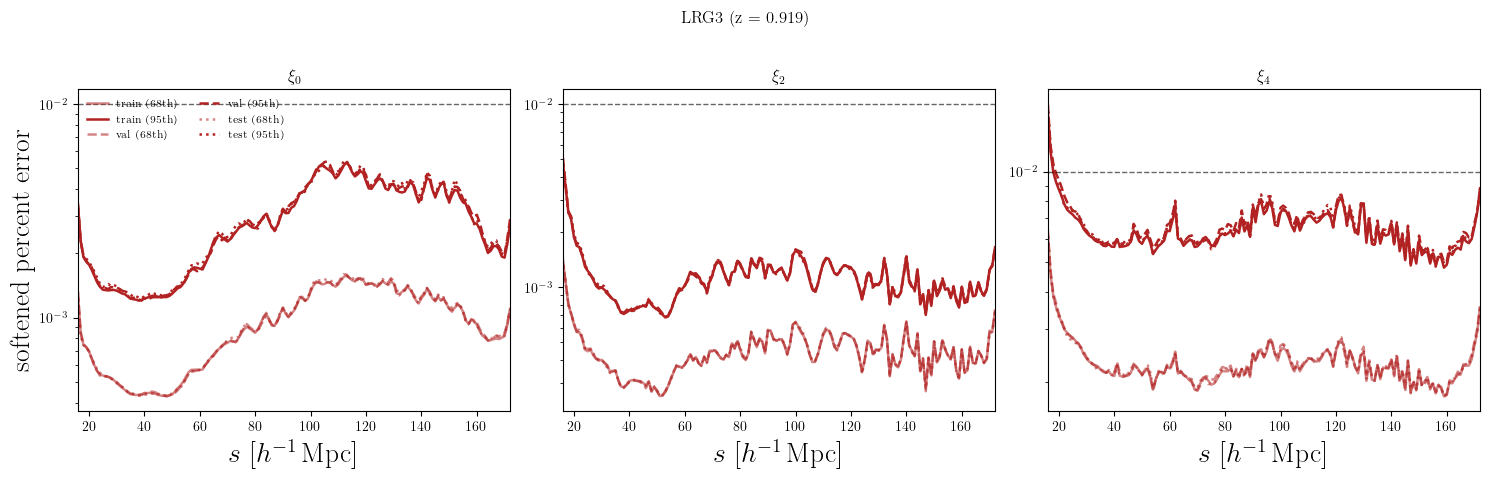

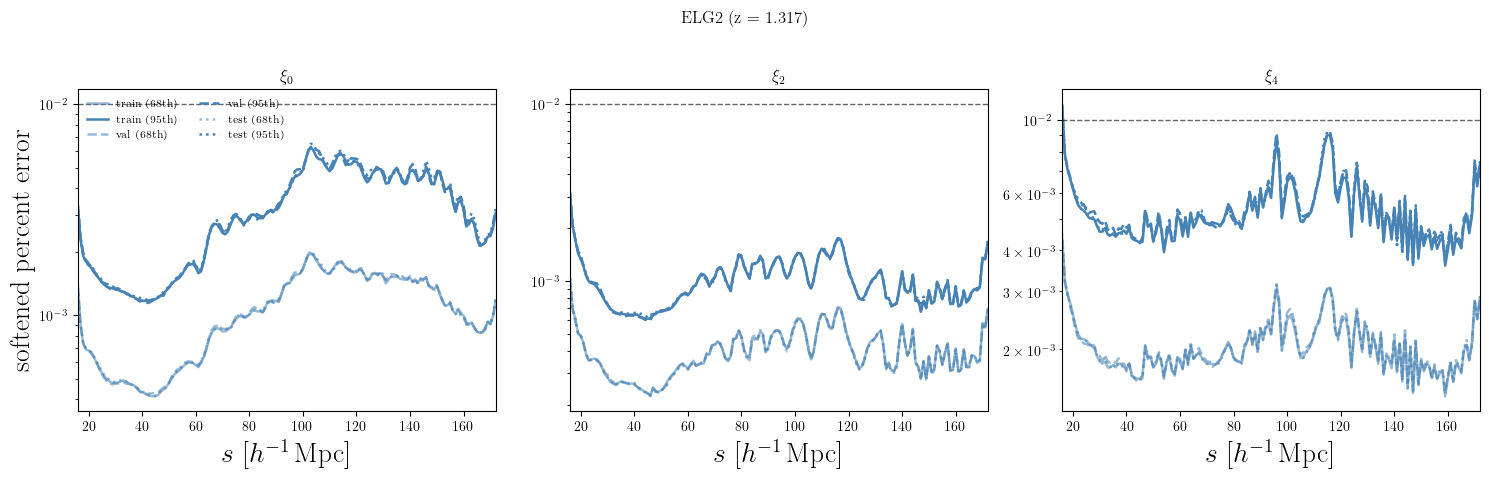

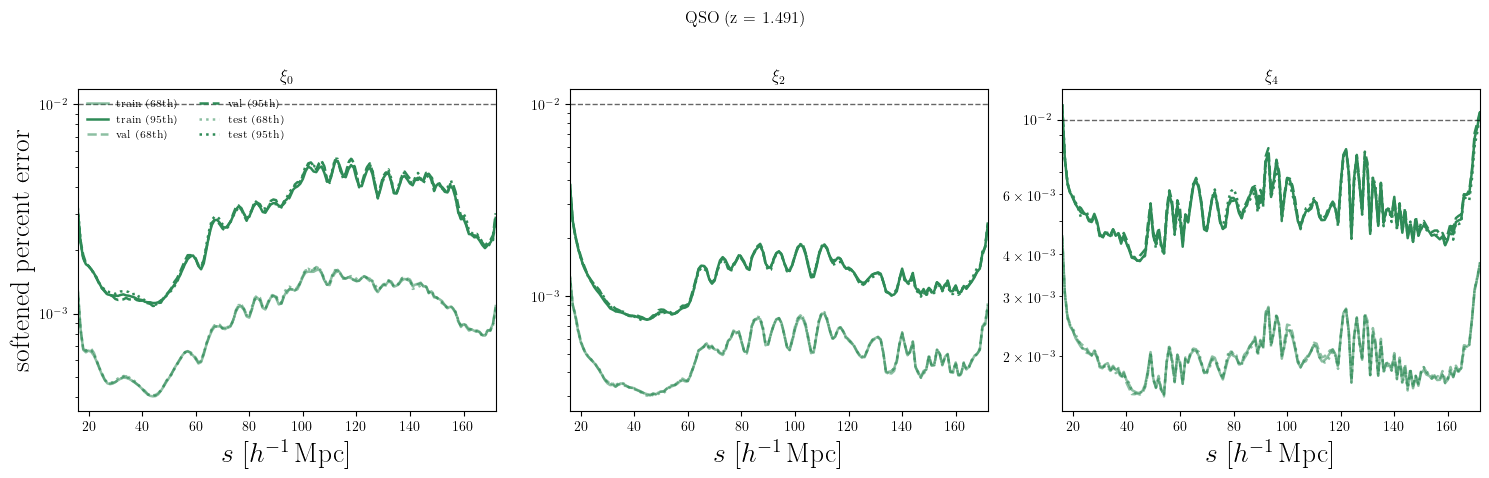

In [8]:
for z in REDSHIFTS:
    tracer_name, base_color = TRACER_COLOR[z]
    z_dir = os.path.join(BASE_DIR, zdir(z))
    s = np.load(os.path.join(z_dir, 's.npy'))

    data = {}
    for split in SPLITS:
        thetas = np.load(os.path.join(z_dir, f'thetas_{split}.npy'))
        xi = np.load(os.path.join(z_dir, f'xi_{split}.npy'))
        data[split] = dict(thetas=thetas, xi=xi)

    _, rough_ref = flag(data['train']['xi'])
    for split in SPLITS:
        bad, _ = flag(data[split]['xi'], rough_ref=rough_ref)
        data[split]['keep'] = ~bad
        print(f"z={z} {split}: excluding {bad.sum()}/{len(bad)}")

    preds = {split: {} for split in SPLITS}
    truths = {split: {} for split in SPLITS}
    sigma_s_train = {}   # softening floor always uses TRAIN's own scatter,
                         # so the metric's denominator means the same thing
                         # across splits rather than each split softening
                         # against its own (differently-sized) sample

    for i, ell in enumerate(ELLS):
        model_path = os.path.join(MODEL_DIR, f'compact_xi{ell}_{zdir(z)}_free_ns')
        emu = NPEmulator(model_path)
        sigma_s_train[ell] = np.std(data['train']['xi'][data['train']['keep']][:, i], axis=0)

        for split in SPLITS:
            th = data[split]['thetas'][data[split]['keep']]
            xi = data[split]['xi'][data[split]['keep']][:, i]
            params = to_params(th)
            _, pred = emu(params)
            preds[split][ell] = pred
            truths[split][ell] = xi

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True)
    for ax, ell in zip(axes, ELLS):
        for split, ls in SPLITS.items():
            frac = soft_frac_pct(preds[split][ell], truths[split][ell], sigma_s_train[ell], 0.3)
            for p in PCTS:
                c = np.percentile(frac, p, axis=0)
                ax.plot(s, c, color=base_color, ls=ls, alpha=SHADE[p], lw=1.8)
        ax.axhline(1e-2, color='k', ls='--', lw=1.0, alpha=0.6)
        ax.set_yscale('log')
        ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
        ax.set_title(rf'$\xi_{ell}$', fontsize=12)
        ax.margins(x=0)

    # build a compact legend by hand -- (split x percentile) combos, not
    # (split x ell) or anything that would duplicate across subplots
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=base_color, ls=ls, alpha=SHADE[p], lw=1.8,
                      label=f'{split} ({p}th)')
              for split, ls in SPLITS.items() for p in PCTS]
    axes[0].set_ylabel('softened percent error')
    axes[0].legend(handles=handles, frameon=False, fontsize=7.5, ncol=2, loc='upper left')
    fig.suptitle(f'{tracer_name}  (z = {z})', y=1.03)
    fig.tight_layout()